In [1]:
from __future__ import print_function
from os.path import join
import time

import numpy as np
import pandas as pd
import pyxis as px
import pyxis.torch as pxt
from astropy.io import fits
import matplotlib.pyplot as plt
import torch

In [18]:
tensor = torch.empty((15, 1, 3, 64), dtype=torch.float, device='cpu')
ds = pxt.TorchDataset('/ocean/projects/phy250048p/shared/datasets/train_1m_low_hlr')
tensor[0] = ds[0]['spec']

RuntimeError: The expanded size of the tensor (3) must match the existing size (5) at non-singleton dimension 1.  Target sizes: [1, 3, 64].  Tensor sizes: [5, 64]

In [9]:
print(tensor.shape)

torch.Size([1, 5, 64])


In [2]:
def normalize(form, data, pars=None):
    '''
    Normalizes data into one of three forms:
    '01': normalize between 0 and 1, pars = (min, max)
    '-11': normalize between -1 and 1, pars = (min, max)
    'std': standardize to center around 0 with std dev of 1, pars = (mean, std)
    '''
    if form == 'std': 
        mean, std = pars if pars is not None else (data.mean(), data.std())
        new_data = (data-mean)/std
        
        return new_data
    
    else:
        min_val, max_val = pars if pars is not None else (np.min(data), np.max(data))
        
        if form == '01':
            new_data = (data - min_val)/(max_val-min_val)
            
            return new_data
        
        elif form == '-11':
            new_data = (2*data - (max_val+min_val))/(max_val-min_val)
            
            return new_data
        
        else:
            raise ValueError("Invalid form, must be '01', '-11', or 'std'.")

In [3]:
par_ranges = \
{
    'g1': [-0.1, 0.1],
    'g2': [-0.1, 0.1],
    'theta_int': [-np.pi, np.pi],
    'sini': [0, 1],
    'v0': [-30, 30],
    'vcirc': [60, 540],
    'rscale': [0.1, 10],
    'hlr': [0.1, 5],
}

### Create database

In [7]:
n = 4000 # number of samples per database entry
N = 250 # number of database entries (number of "parts" in the fits folder)
nspec = 5
dataset_name = 'train_1m_low_hlr'
sample_name = 'train_1m_low_hlr'
data_dir = f'/ocean/projects/phy250048p/shared/fits/{dataset_name}/'
samp_dir = f'/ocean/projects/phy250048p/shared/samples/samples_{sample_name}.csv'
save_dir = f'/ocean/projects/phy250048p/shared/datasets/{dataset_name}'
samples = pd.read_csv(samp_dir)
for i, values in enumerate(par_ranges.values()):
    samples.iloc[:, i+1] = normalize('-11', samples.iloc[:, i+1], values)
samples.to_csv(f'/ocean/projects/phy250048p/shared/samples/normalized/samples_{dataset_name}_normalized.csv', index=False)
    
with px.Writer(dirpath=save_dir, map_size_limit=200000, ram_gb_limit=2) as db:
    
    for index in range(N):
        start = time.time()
        folder = index+1
        img_stack = np.full((n, 1, 48, 48), 0.)
        spec_stack = np.full((n, 1, nspec, 64), 0.)
        start_id = index*n
        file_id = index*n
        ids = np.arange(start_id, start_id+n, dtype=np.uint64)
        fids = np.array(samples.iloc[ids])[:, 1:]

        for i in range(n):
            
            ID = file_id + i

            with fits.open(join(data_dir, f'part_{folder}/gal_{ID}.fits')) as hdu:
                img_stack[i, 0] = hdu[nspec+1].data
                
                specs = np.full((nspec, 64), 0.)
                for k in range(nspec):
                    spec = hdu[k+1].data
                    specs[k, :spec.shape[0]] = spec
                spec_stack[i, 0] = specs
        
        # img_stack = normalize('std', img_stack, (img_mean, img_std))
        # spec_stack = normalize('std', spec_stack, (spec_mean, spec_std))
        
        db.put_samples({'img': img_stack,
                        'spec': spec_stack,
                        'fid_pars': fids,
                        'id': ids})
        t = round(time.time() - start, 2)
        
        print(f'folder {folder} complete, {t} seconds')

folder 1 complete, 166.51 seconds


KeyboardInterrupt: 

#### Code to test if database is generated properly

In [2]:
save_dir = '/ocean/projects/phy250048p/shared/datasets/test_tng_10k'

In [5]:
img_stack = torch.empty((50, 1, 48, 48))
snr = torch.rand((200))*95 + 5

In [7]:
with px.Reader(save_dir) as db:
    print(db)
    print(db[0]['spec'].shape)
    for i in range(50):
        idx = i*10000
        img_stack[i] = torch.from_numpy(db[idx]['img'])

pyxis.Reader
Location:		'/ocean/projects/phy250048p/shared/datasets/test_tng_10k'
Number of samples:	500000
Data keys (0th sample):
	'img' <- dtype: float32, shape: (1, 48, 48)
	'spec' <- dtype: float32, shape: (1, 5, 64)
	'fid_pars' <- dtype: float32, shape: (4,)
	'id' <- dtype: uint64, shape: ()
(1, 5, 64)


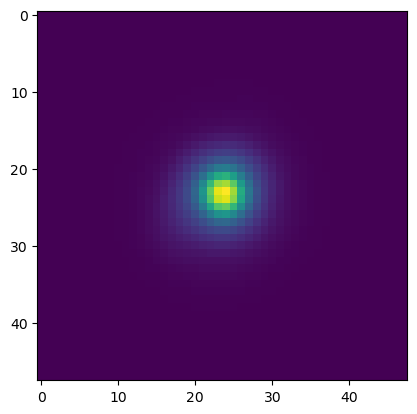

In [16]:
plt.imshow(img_stack[48][0])

In [46]:
noise = torch.randn((200,1, 48,48))

In [89]:
print(torch.sum((noise[0,0]*0.5)**2)**0.5)

tensor(23.9029)


In [162]:
maxs = torch.amax(img_stack, dim=(-1, -2, -3))
seg = img_stack > 0.1*maxs.view(-1, 1, 1, 1)
npix = torch.sum(seg, dim=(-1, -2, -3))
avg = torch.sum(img_stack, dim=(-1, -2, -3))/npix

In [142]:
print(maxs[1])

tensor(76.5059)


In [143]:
factor = avg/snr
data = img_stack + noise*torch.sqrt(factor.view(-1, 1, 1, 1))
mean = data.mean()
std = data.std()

In [153]:
whr = torch.where(snr > 90)

In [158]:
i = whr[0][1]

In [159]:
print(snr[i], avg[i], factor[i])

tensor(97.5421) tensor(59.8838) tensor(0.6139)


In [7]:
plt.imshow(data[i, 0])

NameError: name 'data' is not defined

In [150]:
img_seg = torch.clone(img_stack)
img_seg[~seg] = 0

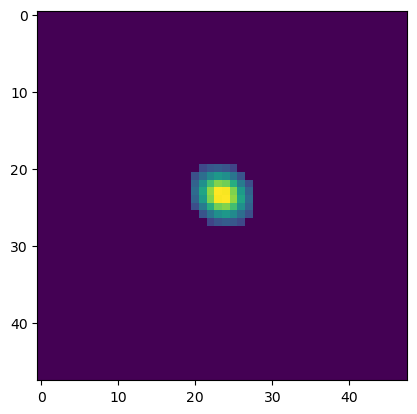

In [161]:
plt.imshow(img_seg[i, 0])

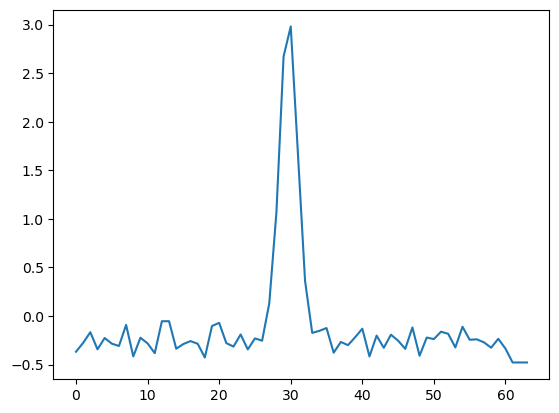

In [40]:
plt.plot(spec[0])